In [1]:
# --- 1. LIBRARIES ---
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_curve, auc)

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (Dense, Conv1D, BatchNormalization, 
                                     concatenate, Flatten, Dropout, Attention, 
                                     Reshape, GlobalAveragePooling1D, Multiply, MaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
# --- 2. REPRODUCIBILITY (The "Same Result" Rule) ---
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)
    print(f"Environment seeds locked at {seed}")

set_seeds(42)

Environment seeds locked at 42


In [3]:
# Load the specific binary dataset
df = pd.read_csv("CIC-IDS-2017_Binary.csv")

# Verify the load by checking the total rows and columns
print(f"Dataset successfully loaded.")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset successfully loaded.
Total Rows: 2827677
Total Columns: 84


In [4]:
df.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Packets/s',
       'Bwd Packets/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count

In [5]:
# 1. Strip any leading/trailing whitespace and convert to lowercase
df.columns = df.columns.str.strip().str.lower()

# 2. Replace spaces, slashes, and dots with underscores for easy coding
df.columns = df.columns.str.replace(' ', '_', regex=False)
df.columns = df.columns.str.replace('/', '_', regex=False)
df.columns = df.columns.str.replace('.', '_', regex=False)

# 3. Print the first 10 columns to verify the change
print("First 10 standardized columns:")
print(df.columns[:10].tolist())

# 4. Find the exact name of your Label column
label_col = [col for col in df.columns if 'label' in col]
print(f"\nLabel column found: {label_col}")

First 10 standardized columns:
['flow_id', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'protocol', 'timestamp', 'flow_duration', 'tot_fwd_pkts', 'tot_bwd_pkts']

Label column found: ['label']


In [6]:
# List of columns that are not useful for training features
identifiers = ['flow_id', 'src_ip', 'dst_ip', 'timestamp']

# Drop them only if they exist in the current dataframe
df.drop(columns=[col for col in identifiers if col in df.columns], inplace=True)

print(f"Identifiers removed.")
print(f"Remaining columns: {df.shape[1]}")

Identifiers removed.
Remaining columns: 80


In [7]:
# 1. Check for any columns that are not integers or floats (excluding 'label')
non_numeric = df.drop(columns=['label']).select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Non-numeric columns found (excluding label): {non_numeric}")

# 2. Check for Infinite values (common in this dataset)
inf_count = np.isinf(df.select_dtypes(include=[np.number])).values.sum()
print(f"Total Infinite values: {inf_count}")

# 3. Check for Null/NaN values
nan_count = df.isnull().sum().sum()
print(f"Total NaN values: {nan_count}")

Non-numeric columns found (excluding label): []
Total Infinite values: 0
Total NaN values: 0


In [8]:
# 1. Check unique values in the label column
print("Unique labels in dataset:")
print(df['label'].unique())

# 2. Check the count of each label to see if it is imbalanced
print("\nLabel counts:")
print(df['label'].value_counts())

# 3. Check the data type of the label
print(f"\nLabel data type: {df['label'].dtype}")

Unique labels in dataset:
[0 1]

Label counts:
label
0    2271122
1     556555
Name: count, dtype: int64

Label data type: int64


In [9]:
# 1. Define Features (X) and Target (y)
X = df.drop(columns=['label'])
y = df['label']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Verification of the split
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set:  {X_test.shape[0]} rows")
print(f"\nAttack percentage in Training: {y_train.mean():.2%}")
print(f"Attack percentage in Testing:  {y_test.mean():.2%}")

Training set: 2262141 rows
Testing set:  565536 rows

Attack percentage in Training: 19.68%
Attack percentage in Testing:  19.68%


In [10]:
# 1. Initialize the Scaler
scaler = MinMaxScaler()

# 2. Fit on training data and transform both sets
# This preserves the default float64 precision
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Verification of the results
print(f"Scaling Complete.")
print(f"Data Type:         {X_train_scaled.dtype}")
print(f"Number of Features: {X_train_scaled.shape[1]}")
print(f"Value Range:       {X_train_scaled.min()} to {X_train_scaled.max()}")

Scaling Complete.
Data Type:         float64
Number of Features: 79
Value Range:       0.0 to 1.0000000000000002


In [11]:
# --- STAGE 1: AUTOENCODER DEFINITION ---

# 1. Use your 79 features as the input dimension
input_dim = X_train_scaled.shape[1]
ae_in = Input(shape=(input_dim,))

# 2. Encoder: Bottleneck strategy (96 neurons -> 32 neurons)
enc = Dense(96, activation='relu')(ae_in)
enc = BatchNormalization()(enc)
enc = Dense(32, activation='relu')(enc) 

# 3. AE Attention Mechanism
# Reshaping to (1, 32) allows the Attention layer to weigh the encoded features
att_reshape = Reshape((1, 32))(enc)
att_logic = Attention()([att_reshape, att_reshape])
att_flat = Flatten()(att_logic)

# 4. Decoder: Reconstruction strategy
# Maps the 32 features back to the original 79 dimensions
dec = Dense(96, activation='tanh')(att_flat)
dec_out = Dense(input_dim, activation='sigmoid')(dec) 

# 5. Model Creation
# 'autoencoder' is for training; 'encoder_only' is for feature extraction
autoencoder = Model(ae_in, dec_out, name="Autoencoder")
encoder_only = Model(ae_in, att_flat, name="Encoder_Extractor")

# 6. Compilation
# Using Adam optimizer and Mean Absolute Error (MAE) loss
autoencoder.compile(optimizer='adam', loss='mae')

# Display the architecture
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 79)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 96)                │           7,680 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 96)                │             384 │ dense[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 32)                │           3,104 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 1, 32)             │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention (Attention)         │ (None, 1, 32)             │               0 │ reshape[0][0],             │
│                               │                           │                 │ reshape[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 32)                │               0 │ attention[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 96)                │           3,168 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 79)                │           7,663 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 21,999 (85.93 KB)

 Trainable params: 21,807 (85.18 KB)

 Non-trainable params: 192 (768.00 B)

In [12]:
# 1. Define Early Stopping to monitor validation loss
early_stop_ae = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

# 2. Train the model
# Input (X_train_scaled) is also the Target (X_train_scaled) for an Autoencoder
print("Starting Autoencoder Training...")
history_ae = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=50,
    batch_size=1024,
    validation_split=0.2,
    callbacks=[early_stop_ae],
    verbose=1
)

print("\nAutoencoder training finished.")

Starting Autoencoder Training...
Epoch 1/50


C:\Users\Hp\AppData\Roaming\Python\Python312\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1768/1768 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0193 - val_loss: 0.0072
Epoch 2/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 0.0067 - val_loss: 0.0060
Epoch 3/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 0.0058 - val_loss: 0.0053
Epoch 4/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0053 - val_loss: 0.0051
Epoch 5/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.0051 - val_loss: 0.0050
Epoch 6/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 7/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.0039 - val_loss: 0.0031
Epoch 8/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - loss: 0.0031 - val_loss: 0.0029
Epoch 9/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.0029 - val_loss: 0.0028
Epoch 10/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 11/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 12/50
1768/1768 ━━━━━━━

In [13]:
# 1. Extract the 32 compressed features using the encoder model
X_train_encoded = encoder_only.predict(X_train_scaled)
X_test_encoded = encoder_only.predict(X_test_scaled)

# 2. Reshape for the CNN (Conv1D)
# New Shape: (Samples, 32, 1)
X_train_cnn = X_train_encoded.reshape(X_train_encoded.shape[0], 32, 1)
X_test_cnn = X_test_encoded.reshape(X_test_encoded.shape[0], 32, 1)

# 3. Verification
print("Feature Extraction & Reshaping Complete.")
print(f"Original shape: {X_train_scaled.shape}")
print(f"Encoded CNN shape: {X_train_cnn.shape}")

  123/70692 ━━━━━━━━━━━━━━━━━━━━ 1:06 949us/step

C:\Users\Hp\AppData\Roaming\Python\Python312\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


70692/70692 ━━━━━━━━━━━━━━━━━━━━ 56s 784us/step
17673/17673 ━━━━━━━━━━━━━━━━━━━━ 13s 732us/step
Feature Extraction & Reshaping Complete.
Original shape: (2262141, 79)
Encoded CNN shape: (2262141, 32, 1)


In [14]:
# --- CNN CLASSIFIER ARCHITECTURE ---

# Input shape is (32, 1) based on the 32 features extracted by the Autoencoder
inp = Input(shape=(X_train_cnn.shape[1], 1), name="CIAM_Input")

# Inception Module: Three parallel branches with 16 filters each
conv1 = Conv1D(16, 1, activation='relu', padding='same', name="Branch_1x1")(inp)
conv3 = Conv1D(16, 3, activation='relu', padding='same', name="Branch_3x3")(inp)
conv5 = Conv1D(16, 5, activation='relu', padding='same', name="Branch_5x5")(inp)

# Merge the branches: 16 + 16 + 16 = 48 total filters
merged = concatenate([conv1, conv3, conv5], axis=-1, name="Inception_Merge")
merged = BatchNormalization(name="Merge_BN")(merged)

# Attention Mechanism: Global Average Pooling -> Dense Weighting -> Multiply
gap = GlobalAveragePooling1D(name="Attention_GAP")(merged)
att_weights = Dense(48, activation='sigmoid', name="Attention_Weights")(gap)
att_weights = Reshape((1, 48), name="Attention_Reshape")(att_weights)
merged_att = tf.keras.layers.Multiply(name="Attention_Apply")([merged, att_weights])

# Classification Head
pooled = tf.keras.layers.MaxPooling1D(pool_size=2, name="Final_Pool")(merged_att)
flat = Flatten(name="Final_Flatten")(pooled)
x = Dense(16, activation='relu', name="Dense_16")(flat)
x = Dropout(0.1, name="Dropout_1")(x)
x = Dense(8, activation='relu', name="Dense_8_A")(x)
x = Dropout(0.1, name="Dropout_2")(x)
x = Dense(8, activation='relu', name="Dense_8_B")(x)

# Output: 2 units for Softmax classification
output = Dense(2, activation='softmax', name="Output_Layer")(x)

# Create the Model object
cnn_binary = Model(inp, output, name="CIAM_Binary_Classifier")

# Display the summary to verify the layers
cnn_binary.summary()

Model: "CIAM_Binary_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ CIAM_Input (InputLayer)       │ (None, 32, 1)             │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Branch_1x1 (Conv1D)           │ (None, 32, 16)            │              32 │ CIAM_Input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Branch_3x3 (Conv1D)           │ (None, 32, 16)            │              64 │ CIAM_Input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Branch_5x5 (Conv1D)           │ (None, 32, 16)            │              96 │ CIAM_Input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Inception_Merge (Concatenate) │ (None, 32, 48)            │               0 │ Branch_1x1[0][0],          │
│                               │                           │                 │ Branch_3x3[0][0],          │
│                               │                           │                 │ Branch_5x5[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Merge_BN (BatchNormalization) │ (None, 32, 48)            │             192 │ Inception_Merge[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Attention_GAP                 │ (None, 48)                │               0 │ Merge_BN[0][0]             │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Attention_Weights (Dense)     │ (None, 48)                │           2,352 │ Attention_GAP[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Attention_Reshape (Reshape)   │ (None, 1, 48)             │               0 │ Attention_Weights[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Attention_Apply (Multiply)    │ (None, 32, 48)            │               0 │ Merge_BN[0][0],            │
│                               │                           │                 │ Attention_Reshape[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Final_Pool (MaxPooling1D)     │ (None, 16, 48)            │               0 │ Attention_Apply[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Final_Flatten (Flatten)       │ (None, 768)               │               0 │ Final_Pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Dense_16 (Dense)              │ (None, 16)                │          12,304 │ Final_Flatten[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Dropout_1 (Dropout)           │ (None, 16)                │               0 │ Dense_16[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Dense_8_A (Dense)             │ (None, 8)                 │             136 │ Dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 15,266 (59.63 KB)

 Trainable params: 15,170 (59.26 KB)

 Non-trainable params: 96 (384.00 B)

In [16]:
# 1. Compile the model
cnn_binary.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Define the training callbacks
callbacks = [
    EarlyStopping(
        patience=5, 
        restore_best_weights=True, 
        monitor='val_accuracy'
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=5, 
        min_lr=1e-7, 
        verbose=1
    )
]

# 3. Start training
print("Starting CIAM Classifier Training...")
history_cnn = cnn_binary.fit(
    X_train_cnn, y_train,
    epochs=30,
    batch_size=1024,
    validation_data=(X_test_cnn, y_test),
    callbacks=callbacks,
    verbose=1
)

Starting CIAM Classifier Training...
Epoch 1/30
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 36s 15ms/step - accuracy: 0.9843 - loss: 0.0376 - val_accuracy: 0.9856 - val_loss: 0.0335 - learning_rate: 1.0000e-04
Epoch 2/30
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.9844 - loss: 0.0374 - val_accuracy: 0.9860 - val_loss: 0.0334 - learning_rate: 1.0000e-04
Epoch 3/30
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9845 - loss: 0.0371 - val_accuracy: 0.9853 - val_loss: 0.0340 - learning_rate: 1.0000e-04
Epoch 4/30
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9847 - loss: 0.0368 - val_accuracy: 0.9860 - val_loss: 0.0332 - learning_rate: 1.0000e-04
Epoch 5/30
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9848 - loss: 0.0367 - val_accuracy: 0.9863 - val_loss: 0.0331 - learning_rate: 1.0000e-04
Epoch 6/30
2210/2210 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9849 - loss: 0.0364 - val_accuracy: 0.9859 - val_loss: 0.0331 - learning_rate: 1.0000e-04
Epo

In [17]:
# 1. Predict on the test set
# np.argmax converts the Softmax output (probabilities for 0 and 1) into the final class (0 or 1)
y_pred_probs = cnn_binary.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Print Accuracy and Classification Report
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.5f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['BENIGN', 'ATTACK']))

# 3. Print Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 4. Save the CNN Classifier
cnn_binary.save("AE_CIAM_Binary_Final.keras")
print("\nClassifier saved as: AE_CIAM_Binary_Final.keras")

17673/17673 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step
Final Test Accuracy: 0.98692

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.99      0.99      0.99    454225
      ATTACK       0.96      0.98      0.97    111311

    accuracy                           0.99    565536
   macro avg       0.98      0.98      0.98    565536
weighted avg       0.99      0.99      0.99    565536


Confusion Matrix:
[[449126   5099]
 [  2297 109014]]

Classifier saved as: AE_CIAM_Binary_Final.keras


In [18]:
import joblib

# 1. Save the Scaler (essential for normalizing new data correctly)
joblib.dump(scaler, "scaler.pkl")

# 2. Save the Encoder (the 32-feature extractor)
encoder_only.save("AE_Encoder_Extractor.keras")

# 3. Save the full Autoencoder (in case you want to fine-tune it later)
autoencoder.save("AE_Stage1_Full.keras")

print("All components saved successfully:")
print("- scaler.pkl (Feature Normalization)")
print("- AE_Encoder_Extractor.keras (Feature Extraction)")
print("- AE_Stage1_Full.keras (Full Autoencoder)")

All components saved successfully:
- scaler.pkl (Feature Normalization)
- AE_Encoder_Extractor.keras (Feature Extraction)
- AE_Stage1_Full.keras (Full Autoencoder)


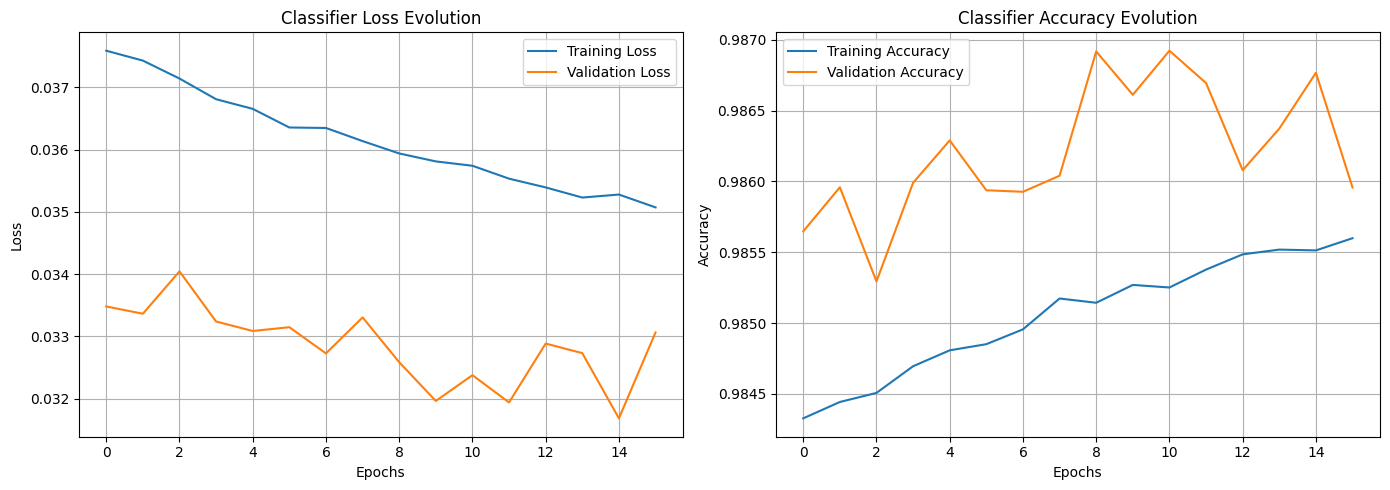

In [19]:
# Create a figure with two subplots
plt.figure(figsize=(14, 5))

# 1. Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Classifier Loss Evolution')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Classifier Accuracy Evolution')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

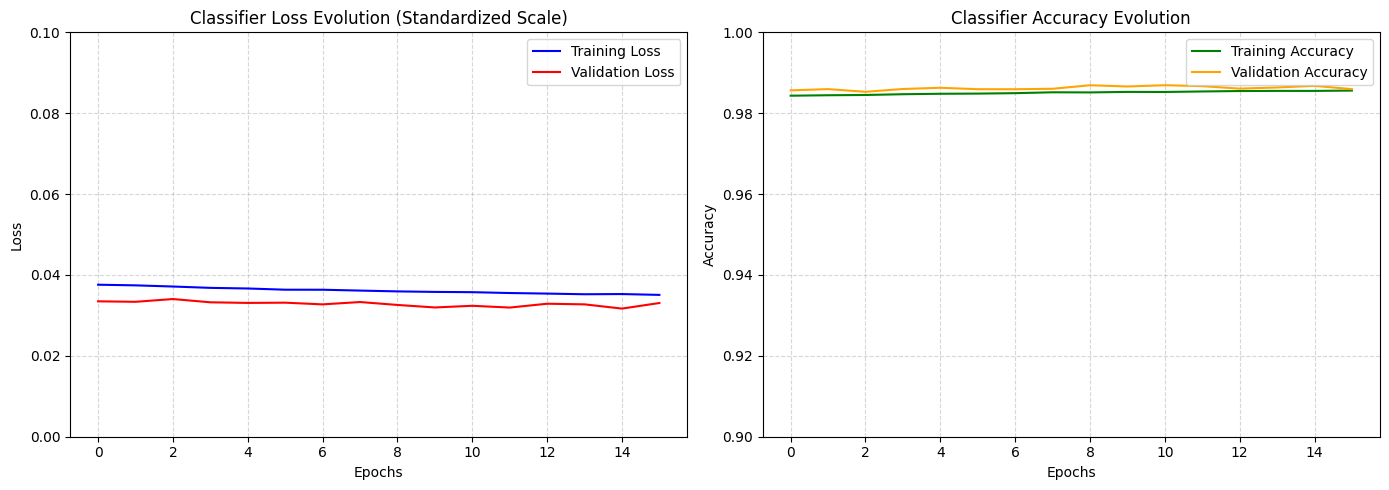

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# 1. Plot Loss with an increased Y-axis range
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='Training Loss', color='blue')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss', color='red')

# --- INCREASE SCALE HERE ---
# By setting the bottom to 0 and top to 0.1, 
# the 0.032 to 0.037 fluctuations will look like a much flatter line.
plt.ylim(0, 0.1) 

plt.title('Classifier Loss Evolution (Standardized Scale)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Plot Accuracy (Zoomed for detail)
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy', color='orange')

# Standard accuracy scale to see the trend without excessive deflection
plt.ylim(0.9, 1.0) 

plt.title('Classifier Accuracy Evolution')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

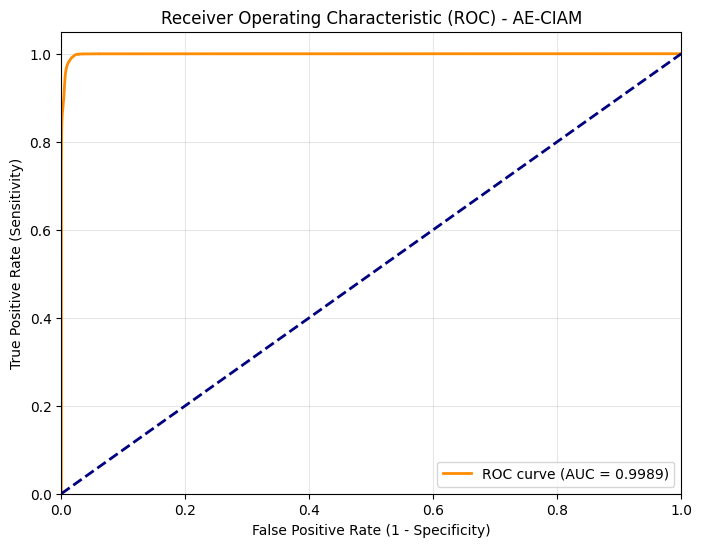

Final AUC Score: 0.99892


In [20]:
from sklearn.metrics import roc_curve, auc

# 1. Get the probability for the "Attack" class (class 1)
# y_pred_probs contains [prob_class_0, prob_class_1]
y_probs_attack = y_pred_probs[:, 1]

# 2. Calculate ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_probs_attack)
roc_auc = auc(fpr, tpr)

# 3. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal line (random guess)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) - AE-CIAM')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Final AUC Score: {roc_auc:.5f}")

In [21]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.5f}")

Matthews Correlation Coefficient (MCC): 0.95914


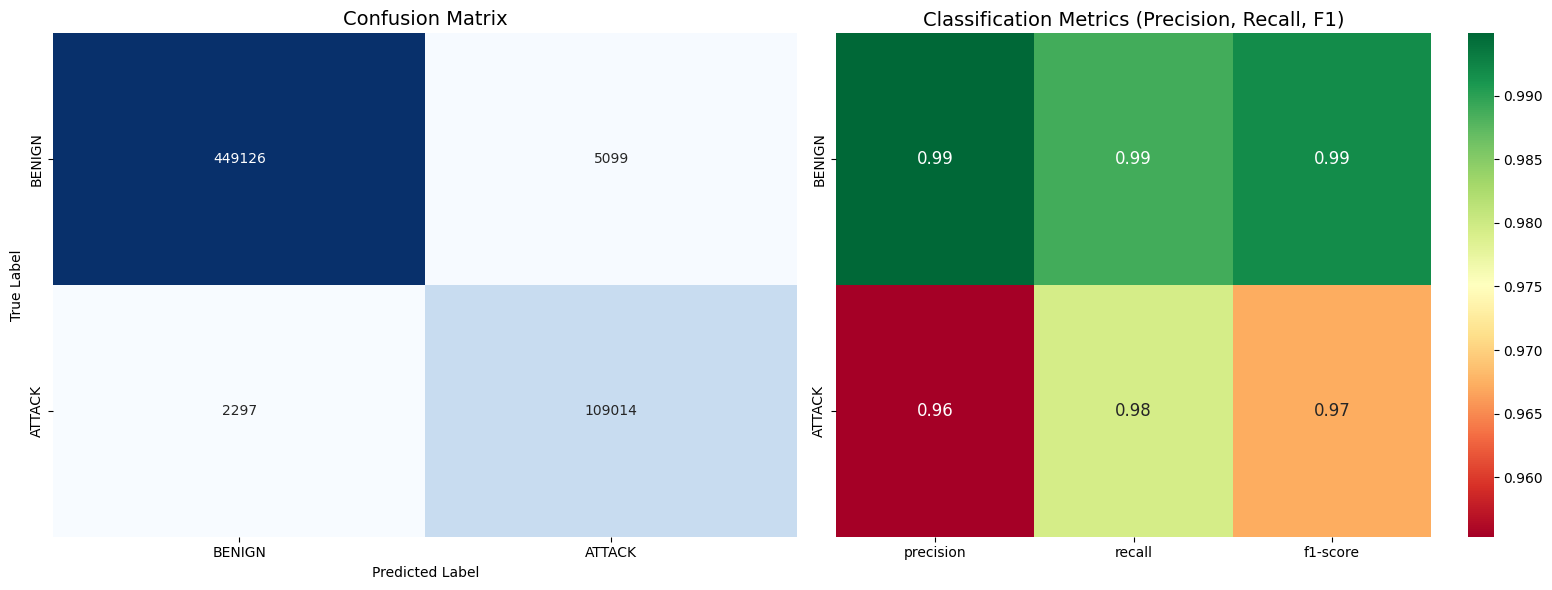

In [22]:
import seaborn as sns
import pandas as pd

# 1. Setup the figure
plt.figure(figsize=(16, 6))

# --- PLOT 1: Confusion Matrix Heatmap ---
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['BENIGN', 'ATTACK'], 
            yticklabels=['BENIGN', 'ATTACK'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# --- PLOT 2: Classification Report Heatmap ---
plt.subplot(1, 2, 2)
# Generate report as a dictionary to convert to a DataFrame
report_dict = classification_report(y_test, y_pred, 
                                    target_names=['BENIGN', 'ATTACK'], 
                                    output_dict=True)
# Convert to DataFrame and remove 'accuracy' and 'support' for a cleaner heatmap
report_df = pd.DataFrame(report_dict).iloc[:-1, :2].T 

sns.heatmap(report_df, annot=True, cmap='RdYlGn', cbar=True, annot_kws={"size": 12})
plt.title('Classification Metrics (Precision, Recall, F1)', fontsize=14)

plt.tight_layout()
plt.show()